In [108]:
import yfinance as yf
import datetime as dt
from itertools import pairwise
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa.stattools import adfuller
from scipy.integrate import quad
from scipy.optimize import root

In [109]:
FIGSIZE = (6.6, 4.2)      # use for ONE pdf figure
# FIGSIZE = (3.3, 2.4)    # use if each plot is saved separately and placed side by side

TITLE_SIZE = 10
LABEL_SIZE = 9
TICK_SIZE = 8
LEGEND_SIZE = 8

LINE_WIDTH = 1.1
THIN_LINE_WIDTH = 0.8
MARKER_SIZE = 5

plt.rcParams.update({
    "font.size": 9,
    "axes.titlesize": TITLE_SIZE,
    "axes.labelsize": LABEL_SIZE,
    "xtick.labelsize": TICK_SIZE,
    "ytick.labelsize": TICK_SIZE,
    "legend.fontsize": LEGEND_SIZE,

    "lines.linewidth": LINE_WIDTH,
    "lines.markersize": MARKER_SIZE,

    "axes.linewidth": 0.8,

    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,

    "pdf.fonttype": 42,
    "ps.fonttype": 42,

    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.04,
})

In [110]:
preday0 = dt.date(2023,1,1)
day0 = dt.date(2024,1,1)
endday =   dt.date(2025,6,1) #  dt.datetime.today() # 

In [111]:
tickers_no  = ["EQNR.OL","AKRBP.OL","SUBC.OL","TGS.OL","AKSO.OL","DNO.OL",
    "MOWI.OL","SALM.OL","LSG.OL","BAKKA.OL",
    "DNB.OL","STB.OL","GJF.OL",
    "YAR.OL","NHY.OL","ELK.OL","TOM.OL","KOG.OL",
    "FRO.OL","BWLPG.OL","WWI.OL"]

tickers_us = [
    
    "JPM", "BAC", "C", "WFC", "GS", "MS",
    "XOM", "CVX", "COP", "EOG", "SLB",
    "NVDA", "AMD", "AVGO", "INTC", "QCOM", "TXN", "MU",
    "DAL", "UAL", "AAL", "LUV", "ALK"
]


tickers0 = [
    "GLD",   # gold
    "SLV",   # silver
    "USO",   # crude oil
    "UNG",   # natural gas
    "CPER",  # copper
    "DBA",   # agriculture
    "GDX",  # gold miners
    "SIL", # silver miners
    "COPX", # copper miners
    "URA",     # uranium
    "PICK",  # metaller og gruver
    "XLE",# energi sektor
    "XOP", # olje og gass sektor
    "NUE", # stål sektor
    "NTR", # fertilizers sektor
    "ALB", # lithium
    "XOM", # Exxon Mobile
    
]
tickersc = [
    "NOKUSD=X", # NOKUSD
    "SEKUSD=X" #SEKUSD
]

tickersm = ["GLD", "GDX"]
tickers = ["BTC-USD","ETH-USD"]

In [112]:
data = yf.download(tickers,start=preday0, end=endday)

[*********************100%***********************]  2 of 2 completed


In [113]:
data = data['Close'].dropna()
len(data)


882

In [114]:
data0 = data[:][preday0:endday]
len(data0)


882

In [115]:
R = data0.pct_change().dropna()

In [116]:
resultater = []

for a, b in pairwise(R.columns):
    # Bruk vektorisert beregning (mye raskere enn for-løkke med [t])
    diff_sum_sq = ((R[a] - R[b])**2).sum()
    
    # Lagre som en dict i listen
    resultater.append({'Par': f"{a} - {b}", 'Kvadratavvik': diff_sum_sq})

# Lag en ny DataFrame og sorter den
df_resultat = pd.DataFrame(resultater)
df_sortert = df_resultat.sort_values(by='Kvadratavvik', ascending=True)

print(df_sortert)

                 Par  Kvadratavvik
0  BTC-USD - ETH-USD      0.336896


In [117]:
#Aticker = "COPX"
#Bticker = "CPER"
#Aticker = "GDX"
#Bticker = "GLD"
#Aticker = "SIL"
#Bticker = "SLV"
#Bticker = "GDX"
#Aticker = "GLD"
#Aticker = "EQNR.OL"
#Bticker = "AKRBP.OL"
#Aticker = "NOKUSD=X"
#Bticker = "SEKUSD=X"
Aticker = "BTC-USD"
Bticker = "ETH-USD"
A = data0[Aticker]
B = data0[Bticker]

In [118]:
def estimator(A,B):

    beta = (A @ B)/(B @ B)
    
    X = A - beta * B
    X = np.array(X)
    n = len(A)
    Xx = np.sum(X[:-1])
    Xy = np.sum(X[1:])
    Xxx = X[:-1] @ X[:-1]
    Xxy = X[:-1] @ X[1:]
    Xyy = X[1:] @ X[1:]

    mu = (Xy*Xxx - Xx*Xxy)/(n*(Xxx - Xxy)-(Xx**2- Xx*Xy))
    theta = -np.log((Xxy - mu * Xx - mu* Xy + n * mu**2)/(Xxx - 2 * mu * Xx + n * mu**2))

    sigma2 = ((2 * theta)/(n * (1-np.exp(-2*theta))))*(Xyy - 2*np.exp(-theta)*Xxy + 
                                             np.exp(-2*theta)*Xxx 
                                             - 2*mu*(1-np.exp(-theta))
                                            *(Xy-np.exp(-theta)*Xx) 
                                            + n*mu**2 * (1-np.exp(-theta))**2)
    

    sigma = np.sqrt(sigma2)

    
    return X, mu, theta, sigma

In [119]:
def plot( X,mu, theta,sigma):
    X0 = X[0]         # Initial value
    T = len(X)         # Total time
    dt = 1        # Time step
    N = int(T / dt)  # Number of time steps

    Xsim = np.zeros(N)
    Xsim[0] = X0

    # Generate the OU process
    for t in range(1, N):
        dW = np.sqrt(dt) * np.random.normal(0, 1)
        Xsim[t] = Xsim[t-1] + theta * (mu - Xsim[t-1]) * dt + sigma * dW

    # Plot the result
    dates = A.index
    fig, ax = plt.subplots()

    ax.plot(dates, X, label="Real Spread")

    ax.set_title("Ornstein-Uhlenbeck Process Simulation")
    ax.set_ylabel("X(t)")

    # Major ticks: months, minor: weeks
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    ax.xaxis.set_minor_locator(mdates.MonthLocator())

    # Financial-style grid
    ax.grid(True, which="major", linestyle="-", alpha=0.4)
    ax.grid(True, which="minor", linestyle=":", alpha=0.2)

    fig.autofmt_xdate()
    ax.legend()
    plt.show()
    res = adfuller(X,regression="c",autolag="AIC")
    print("ADF stat: ", res[0],"P verdi: ",res[1])
    

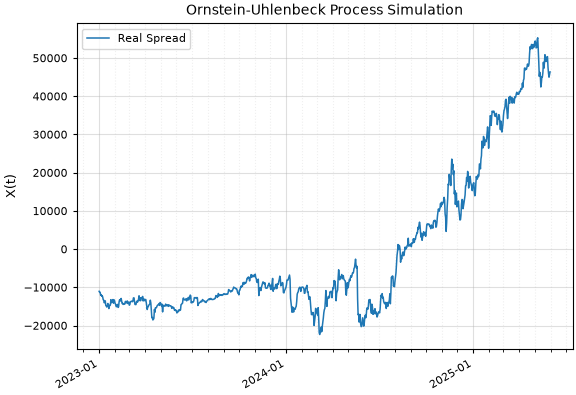

ADF stat:  0.453719270160051 P verdi:  0.9833964359413512


In [120]:

plot(*estimator(A,B))

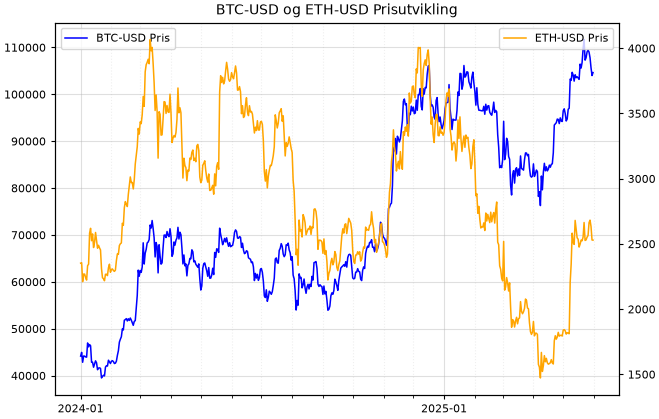

/tmp/ipykernel_1035448/4266458834.py:170: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(


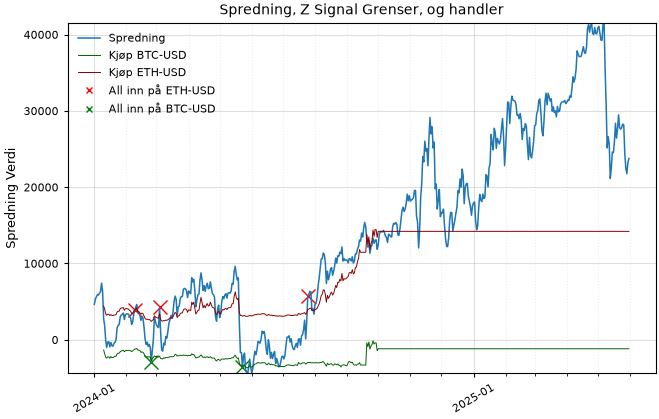

Antall handelsdager: 517
Halveringstid: 125.64 og lengde på vinduet: 251
Antall bytter: 5
Siste posisjon: B
Passiv porteføljeverdi alt i BTC-USD: 236912.87
Passiv porteføljeverdi alt i ETH-USD: 107514.24
Passiv porteføljeverdi 50/50: 172213.55
Aktiv OU Z-verdi porteføljeverdi: 140937.61
Mellom datoer fra: 2024-01-01 til 2025-05-31
ADF stat: -1.3635492464795014 P verdi: 0.5996210188791137


In [ ]:



date = day0

Portfolio0 = 100000.0
Portfolio = Portfolio0

entry = 1

bench_data = data.loc[day0:endday]
dates = bench_data.index

A_full = bench_data[Aticker]
B_full = bench_data[Bticker]

A0 = A_full.iloc[0]
B0 = B_full.iloc[0]

# Start neutral: 50/50 until first signal
sharesA = 0.5 * Portfolio / A0
sharesB = 0.5 * Portfolio / B0
holding = "50/50"

passive_portfolio_A = Portfolio0 * A_full.iloc[-1] / A_full.iloc[0]
passive_portfolio_B = Portfolio0 * B_full.iloc[-1] / B_full.iloc[0]
passive_portfolio_50_50 = (
    0.5 * Portfolio0 * A_full.iloc[-1] / A_full.iloc[0]
    + 0.5 * Portfolio0 * B_full.iloc[-1] / B_full.iloc[0]
)

A_pre = data[Aticker].loc[:day0]
B_pre = data[Bticker].loc[:day0]

X_pre, mu, theta, sigma = estimator(A_pre, B_pre)

half_life = np.log(2) / theta
lookback = int(half_life * 2)
FIGSIZE = (6.6,4.2)
fig, ax = plt.subplots(figsize=FIGSIZE, constrained_layout=True)

ax.plot(dates, A_full, label=f'{Aticker} Pris', color="blue", linewidth=LINE_WIDTH)
ax.set_title(f'{Aticker} og {Bticker} Prisutvikling')
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.xaxis.set_minor_locator(mdates.MonthLocator())
ax.grid(True, which="major", linestyle="-", alpha=0.4)
ax.grid(True, which="minor", linestyle=":", alpha=0.2)

axr = ax.twinx()
axr.plot(dates, B_full, label=f'{Bticker} Pris', color="orange", linewidth=LINE_WIDTH)

ax.legend(loc="upper left")
axr.legend(loc="upper right")

plt.show()


number_of_trades = 0

X_plot = []
plot_dates = []

enter_long = []   
enter_short = []  
FIOGSIZE = (3.3,2.4)
fig, ax = plt.subplots(figsize=FIGSIZE, constrained_layout=True)

for date in dates:
    cur_data = data.loc[:date].tail(lookback)

    A = cur_data[Aticker]
    B = cur_data[Bticker]

    X, mu, theta, sigma = estimator(A, B)

    x_now = X.iloc[-1] if hasattr(X, "iloc") else X[-1]

    A_now = A.iloc[-1]
    B_now = B.iloc[-1]

   
    Portfolio = sharesA * A_now + sharesB * B_now

    t05 = np.log(2) / theta if theta > 0 else np.inf

    skip_entry = (
        theta <= 0 or sigma <= 0 or
        not np.isfinite(theta) or not np.isfinite(sigma) or
        t05 > lookback / 4
    )

    if skip_entry:
        if len(enter_long) > 0:
            lower = enter_long[-1]
            upper = enter_short[-1]
        else:
            lower = np.nan
            upper = np.nan
    else:
        sigma_s = sigma / np.sqrt(2 * theta)

        upper = mu + entry * sigma_s  
        lower = mu - entry * sigma_s  

    enter_short.append(upper)
    enter_long.append(lower)

    plot_dates.append(date)
    X_plot.append(x_now)

    if not skip_entry:
        # X is high: expect X to fall, so hold B
        if x_now >= upper and holding != "B":
            sharesA = 0.0
            sharesB = Portfolio / B_now
            holding = "B"
            number_of_trades += 1

            ax.plot(date, x_now, marker="x", color="red", markersize=10)

        # X is low: expect X to rise, so hold A
        elif x_now <= lower and holding != "A":
            sharesA = Portfolio / A_now
            sharesB = 0.0
            holding = "A"
            number_of_trades += 1

            ax.plot(date, x_now, marker="x", color="green", markersize=10)

# Final portfolio value
Portfolio = sharesA * A_full.iloc[-1] + sharesB * B_full.iloc[-1]

ax.plot(plot_dates, X_plot, label="Spredning", linewidth=LINE_WIDTH)

ax.plot(
    plot_dates,
    enter_long,
    color="darkgreen",
    linewidth=0.7,
    label=f"Kjøp {Aticker}"
)

ax.plot(
    plot_dates,
    enter_short,
    color="darkred",
    linewidth=0.7,
    label=f"Kjøp {Bticker}"
)

ax.plot([], [], marker="x", color="red", linestyle="None",
        markersize=MARKER_SIZE, label=f"All inn på {Bticker}")

ax.plot([], [], marker="x", color="green", linestyle="None",
        markersize=MARKER_SIZE, label=f"All inn på {Aticker}")

ax.set_title("Spredning, Z Signal Grenser, og handler")
ax.set_ylabel("Spredning Verdi")

ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.xaxis.set_minor_locator(mdates.MonthLocator())

ax.grid(True, which="major", linestyle="-", alpha=0.4)
ax.grid(True, which="minor", linestyle=":", alpha=0.2)

ax.legend(fontsize=LEGEND_SIZE, frameon=False)
ax.tick_params(axis="x", labelsize=TICK_SIZE, rotation=30)
ax.tick_params(axis="y", labelsize=TICK_SIZE)

ax.set_ylim(np.nanmin(X_plot) , np.nanmax(X_plot))
fig.subplots_adjust(
    left=0.10,
    right=0.97,
    bottom=0.18,
    top=0.88
)
fig.savefig(f"../figures/zsignal_{Aticker}_{Bticker}_{day0}-{endday}_plot.pdf",bbox_inches="tight", pad_inches=0.04)
plt.show()



print("Antall handelsdager:", len(dates))
print("Halveringstid:", round(half_life, 2), "og lengde på vinduet:", lookback)
print("Antall bytter:", number_of_trades)
print("Siste posisjon:", holding)

print(f"Passiv porteføljeverdi alt i {Aticker}:", round(passive_portfolio_A, 2))
print(f"Passiv porteføljeverdi alt i {Bticker}:", round(passive_portfolio_B, 2))
print("Passiv porteføljeverdi 50/50:", round(passive_portfolio_50_50, 2))

print("Aktiv OU Z-verdi porteføljeverdi:", round(Portfolio, 2))
print("Mellom datoer fra:", dates[0].date(), "til", dates[-1].date())

res = adfuller(X_plot, regression="c", autolag="AIC")
print("ADF stat:", res[0], "P verdi:", res[1])
